# NBA Prediction Market Simulator
### ECON 481 — Business Decisions | Taran Ahluwalia

---

## Research Question

> **How do NBA game prediction market probabilities evolve over the life of a market, and can we build a simulator that generates statistically realistic probability paths for upcoming games?**

## Background

**Prediction markets** are financial markets where contracts pay out based on the outcome of a future event. On [Kalshi](https://kalshi.com), a regulated prediction market exchange, traders buy and sell contracts on outcomes like 'Will the New York Knicks win tonight?'

- A contract priced at **70 cents** implies a **70% market-implied probability**.
- Prices update continuously as traders incorporate new information.
- Under the **Efficient Market Hypothesis (EMH)**, price changes should be unpredictable.

## Data

- **Source:** Kalshi public REST API
- **Markets:** KXNBAGAME series — binary outcome markets on NBA game winners.
- **Unit of observation:** Individual trade records with timestamp and yes-price (cents, 1-99).

---
## 1. Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams['figure.dpi'] = 110
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)

from auxiliary import kalshi, simulator, plots, tables

print('All modules loaded successfully.')
print(f'NumPy {np.__version__} | Pandas {pd.__version__}')

All modules loaded successfully.
NumPy 2.4.2 | Pandas 3.0.0


---
## 2. Data Collection

### 2.1 Current Open NBA Game Markets

In [2]:
open_markets = kalshi.get_nba_markets(series_ticker='KXNBAGAME', status='open', limit=200)
print(f'Open NBA game markets: {len(open_markets)}')
if not open_markets.empty:
    show = [c for c in ['ticker', 'title', 'subtitle', 'last_price', 'volume', 'close_time']
            if c in open_markets.columns]
    print(open_markets[show].to_string(index=False))

Open NBA game markets: 42
                     ticker                                title subtitle  last_price  volume                close_time
KXNBAGAME-26FEB12DALLAL-LAL      Dallas at Los Angeles L Winner?                   75     880 2026-02-27 03:00:00+00:00
KXNBAGAME-26FEB12DALLAL-DAL      Dallas at Los Angeles L Winner?                   29    1022 2026-02-27 03:00:00+00:00
KXNBAGAME-26FEB12PORUTA-UTA             Portland at Utah Winner?                   41     510 2026-02-27 02:00:00+00:00
KXNBAGAME-26FEB12PORUTA-POR             Portland at Utah Winner?                   73    1408 2026-02-27 02:00:00+00:00
KXNBAGAME-26FEB12MILOKC-OKC   Milwaukee at Oklahoma City Winner?                   85     457 2026-02-27 00:30:00+00:00
KXNBAGAME-26FEB12MILOKC-MIL   Milwaukee at Oklahoma City Winner?                   14     607 2026-02-27 00:30:00+00:00
KXNBAGAME-26FEB11MEMDEN-MEM            Memphis at Denver Winner?                   15    5350 2026-02-26 02:00:00+00:00
KXNBAGAME-26FE

### 2.2 Settled (Resolved) Historical Markets

In [3]:
settled_markets = kalshi.get_settled_games(series_ticker='KXNBAGAME', n_games=200)
print(f'Settled NBA game markets: {len(settled_markets)}')
if not settled_markets.empty:
    show = [c for c in ['ticker', 'title', 'result', 'last_price', 'volume']
            if c in settled_markets.columns]
    print(settled_markets[show].head(15).to_string(index=False))

Settled NBA game markets: 200
                     ticker                                  title result  last_price   volume
KXNBAGAME-26FEB09MEMGSW-MEM        Memphis at Golden State Winner?     no           1  5443189
KXNBAGAME-26FEB09MEMGSW-GSW        Memphis at Golden State Winner?    yes          99  4806012
KXNBAGAME-26FEB09CLEDEN-DEN            Cleveland at Denver Winner?     no           1  5696082
KXNBAGAME-26FEB09CLEDEN-CLE            Cleveland at Denver Winner?    yes          99  6298295
KXNBAGAME-26FEB09PHIPOR-POR       Philadelphia at Portland Winner?    yes          99  1748661
KXNBAGAME-26FEB09PHIPOR-PHI       Philadelphia at Portland Winner?     no           1  4321385
KXNBAGAME-26FEB09OKCLAL-OKC Oklahoma City at Los Angeles L Winner?    yes          99  8598943
KXNBAGAME-26FEB09OKCLAL-LAL Oklahoma City at Los Angeles L Winner?     no           1 13212378
KXNBAGAME-26FEB09SACNOP-SAC      Sacramento at New Orleans Winner?     no           1  1095556
KXNBAGAME-26FEB09SAC

### 2.3 Pull Trade Histories for Historical Games

In [4]:
if not settled_markets.empty and 'volume' in settled_markets.columns:
    top_settled = settled_markets.nlargest(20, 'volume')['ticker'].tolist()
elif not settled_markets.empty:
    top_settled = settled_markets['ticker'].head(20).tolist()
else:
    top_settled = []

print(f'Fetching trade histories for {len(top_settled)} settled games...')
histories = kalshi.build_price_histories(top_settled, limit_per_market=5000)
print(f'Successfully retrieved histories for {len(histories)} games.')

for ticker, df in list(histories.items())[:5]:
    short = ticker.split('-')[-1]
    dur = (df['datetime'].max() - df['datetime'].min()).total_seconds() / 60
    print(f'  {short:<12} {len(df):>5} trades  |  {dur:.0f} min  |  '
          f'open={df["probability"].iloc[0]:.2f}  close={df["probability"].iloc[-1]:.2f}')

Fetching trade histories for 20 settled games...
Successfully retrieved histories for 20 games.
  LAL           5000 trades  |  9 min  |  open=0.10  close=0.01
  LAL           5000 trades  |  37 min  |  open=0.81  close=0.99
  DEN           5000 trades  |  12 min  |  open=0.46  close=0.01
  OKC           5000 trades  |  14 min  |  open=0.94  close=0.99
  BOS           5000 trades  |  11 min  |  open=0.77  close=0.99


In [5]:
live_ticker = None
live_trades = None
if not open_markets.empty and 'volume' in open_markets.columns:
    live_ticker = open_markets.nlargest(1, 'volume').iloc[0]['ticker']
elif not open_markets.empty:
    live_ticker = open_markets.iloc[0]['ticker']

if live_ticker:
    live_trades = kalshi.get_market_trades(live_ticker, limit=5000)
    print(f'Live market: {live_ticker}')
    if live_trades is not None:
        p_now = live_trades['probability'].iloc[-1]
        print(f'Trades: {len(live_trades)} | Current implied probability: {p_now:.1%}')

Live market: KXNBAGAME-26FEB10INDNYK-NYK
Trades: 5000 | Current implied probability: 85.0%


---
## 3. Exploratory Data Analysis

### Table 1 — Summary Statistics: Open NBA Game Markets

In [6]:
if not open_markets.empty:
    t1 = tables.create_table1(open_markets)
    print('Table 1: Summary Statistics — Open NBA Game Markets')
    print(t1.to_string())

Table 1: Summary Statistics — Open NBA Game Markets
               count       mean        std     min      25%       50%       75%         max
Last Price    42.000     51.210     25.200  11.000   29.250    51.000    73.750      90.000
Volume        42.000 241091.240 546834.350 457.000 5191.750 15657.500 64510.250 2124932.000
Open Interest 42.000 206970.830 459622.360 457.000 4974.750 14449.500 58474.000 1869643.000


### Figure 1 — Distribution of Market Probabilities

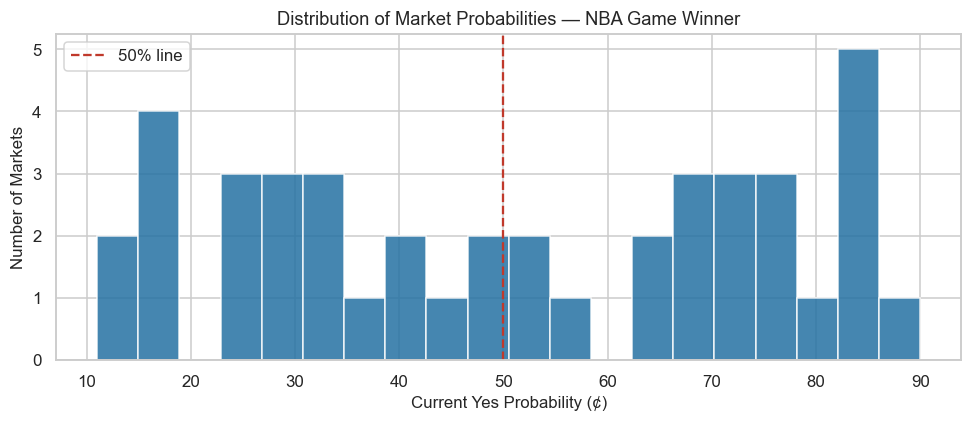

In [7]:
if not open_markets.empty:
    fig = plots.plot_opening_distribution(open_markets, series_label='NBA Game Winner')
    plt.show()

### Figure 2 — Live Probability Path

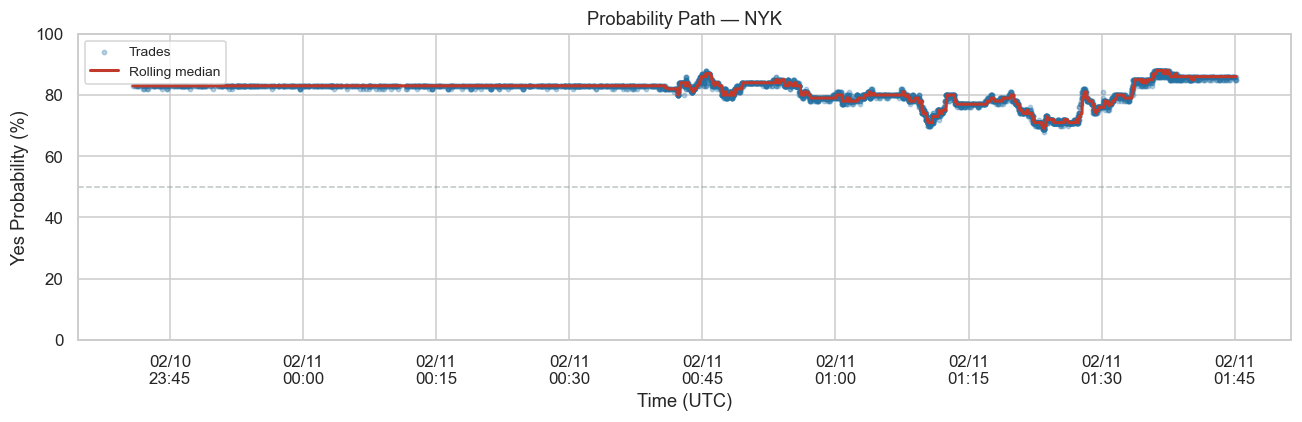

In [8]:
if live_trades is not None:
    plots.plot_probability_path(live_trades, ticker=live_ticker)
else:
    print('No live market data available.')

### Figure 3 — Normalised Historical Probability Paths

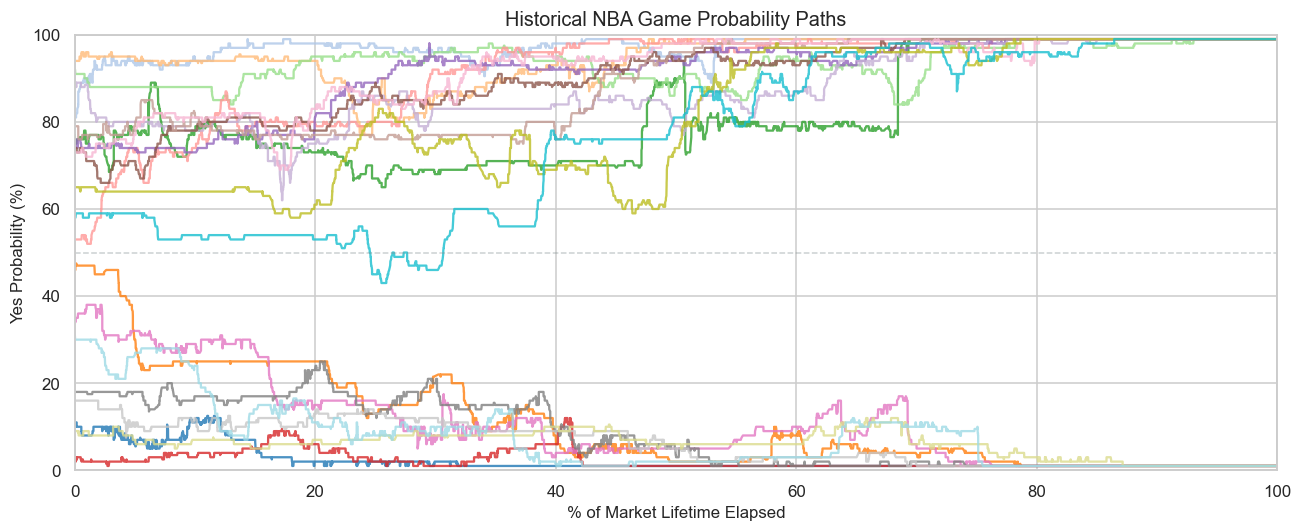

In [9]:
if histories:
    fig = plots.plot_figure1(histories)
    plt.show()
else:
    print('No historical data available.')

### Table 2 — Per-Game Market Statistics

In [10]:
if histories:
    t2 = tables.create_market_summary(histories)
    print('Table 2: Per-Market Summary Statistics')
    print(t2.to_string(index=False))

Table 2: Per-Market Summary Statistics
                     ticker  n_trades  duration_min  open_prob  close_prob  max_prob  min_prob  logit_volatility
KXNBAGAME-26FEB09OKCLAL-LAL      5000         8.800      0.100       0.010     0.170     0.010             0.263
KXNBAGAME-26FEB05PHILAL-LAL      5000        36.600      0.810       0.990     0.990     0.810             0.218
KXNBAGAME-26FEB04DENNYK-DEN      5000        12.000      0.460       0.010     0.480     0.010             0.179
KXNBAGAME-26FEB09OKCLAL-OKC      5000        13.800      0.940       0.990     0.990     0.760             0.162
KXNBAGAME-26FEB06MIABOS-BOS      5000        11.000      0.770       0.990     0.990     0.450             0.148
KXNBAGAME-26FEB09DETCHA-DET      5000        32.200      0.920       0.990     0.990     0.810             0.177
KXNBAGAME-26FEB05PHILAL-PHI      5000        28.900      0.020       0.010     0.140     0.010             0.226
KXNBAGAME-26FEB06LACSAC-LAC      5000        31.600      

### Figure 4 — Volatility Term Structure

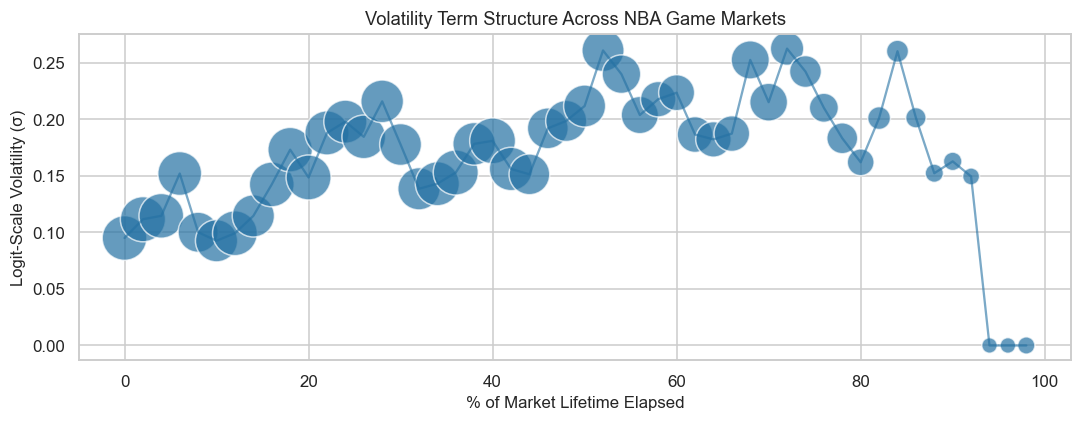

In [11]:
if histories:
    fig = plots.plot_volatility_term_structure(histories, n_steps=50)
    plt.show()
else:
    print('No historical data available.')

---
## 4. Statistical Model — Logit-Scale Random Walk

The probability p(t) is bounded in (0, 1). We model it on the logit scale:

    theta(t) = logit(p(t)) = log(p(t) / (1 - p(t)))
    d theta   = sigma * dW       (Brownian motion)
    p(t)      = sigmoid(theta(t))

Sigma is estimated from historical data. The martingale property is preserved, consistent with the EMH.

In [12]:
if histories:
    sigma = simulator.estimate_volatility(histories, n_steps=100)
else:
    sigma = 0.15

print(f'Estimated logit-scale volatility (sigma): {sigma:.4f}')

Estimated logit-scale volatility (sigma): 0.2320


---
## 5. Simulation

### 5.1 Monte Carlo Fan Chart

In [13]:
# --- CHOOSE YOUR MARKET ---
# Pick any ticker from the open_markets table in Section 2.1
# The ticker ending (-SAS, -NYK, etc.) is the team the "Yes" contract is for
# Examples:
#   'KXNBAGAME-26FEB10SASLAL-SAS'  — San Antonio (85¢ favourite, today)
#   'KXNBAGAME-26FEB10INDNYK-NYK'  — New York Knicks (70¢, today)
#   'KXNBAGAME-26FEB11DETTOR-DET'  — Detroit (57¢, tomorrow)
#   'KXNBAGAME-26FEB11WASCLE-CLE'  — Cleveland (91¢ favourite, tomorrow)

live_ticker = 'KXNBAGAME-26FEB10INDNYK-IND'   # ← change this to your chosen market

live_trades = kalshi.get_market_trades(live_ticker, limit=5000)
if live_trades is not None:
    p_now = live_trades['probability'].iloc[-1]
    print(f'Market : {live_ticker}')
    print(f'Trades : {len(live_trades)}')
    print(f'Current probability: {p_now:.1%}')
else:
    print('Could not retrieve trades — check the ticker string.')

Market : KXNBAGAME-26FEB10INDNYK-IND
Trades : 5000
Current probability: 15.0%


In [14]:
if live_trades is not None:
    p0 = float(live_trades['probability'].iloc[0])
else:
    p0 = 0.65

N_SIMS  = 500
N_STEPS = 100

mc_paths = simulator.simulate_paths(p0=p0, n_steps=N_STEPS, sigma=sigma,
                                    n_sims=N_SIMS, seed=42)
print(f'Opening probability: {p0:.1%}')
print(f'Simulated {mc_paths.shape[0]} paths x {mc_paths.shape[1]} time steps.')

Opening probability: 24.0%
Simulated 500 paths x 101 time steps.


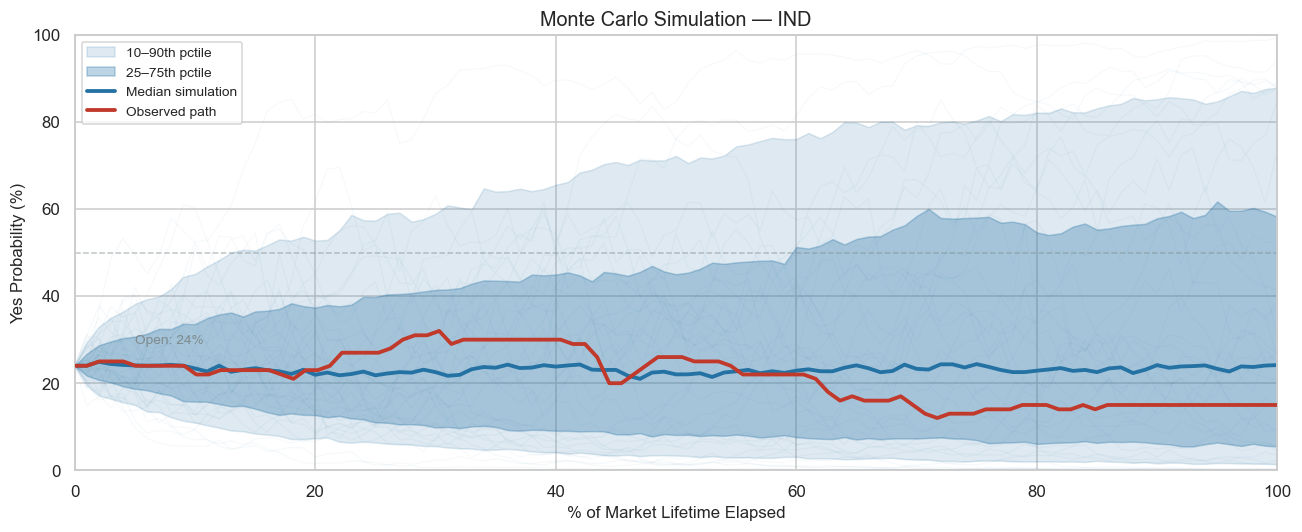

In [15]:
observed_path = None
if live_trades is not None and len(live_trades) > 1:
    observed_path = simulator.resample_to_grid(live_trades, n_steps=N_STEPS)

short_name = live_ticker.split('-')[-1] if live_ticker else 'NBA Game'
fig = plots.plot_fan_chart(mc_paths, actual_path=observed_path, p0=p0,
                           title=f'Monte Carlo Simulation — {short_name}')
plt.show()

### 5.2 Bootstrap Fan Chart

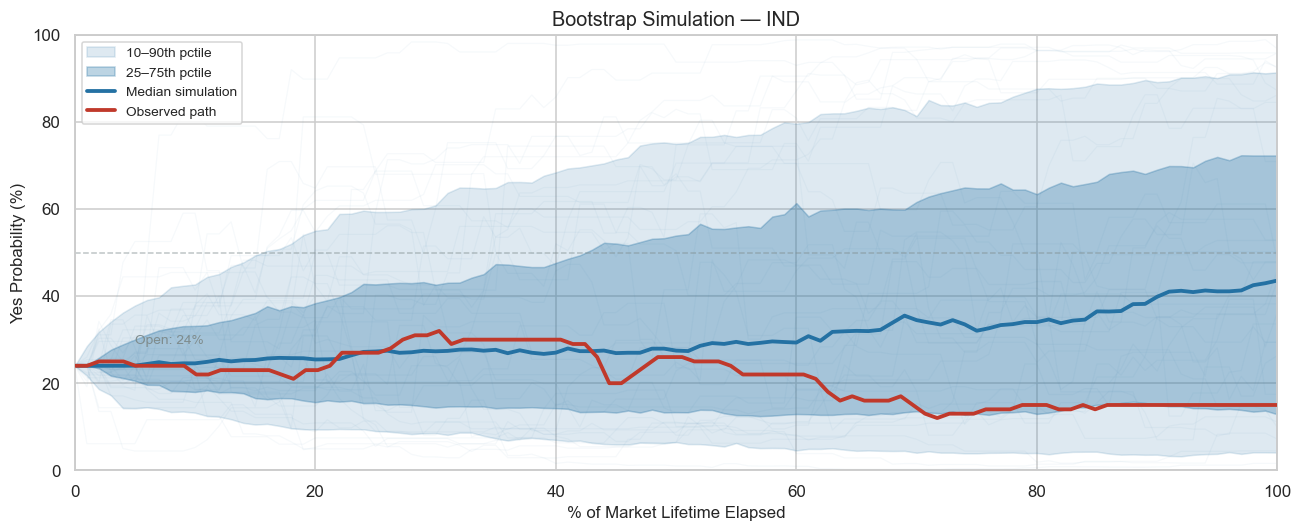

In [16]:
if histories:
    boot_paths = simulator.bootstrap_paths(histories=histories, p0=p0,
                                           n_sims=N_SIMS, n_steps=N_STEPS, seed=42)
    fig = plots.plot_fan_chart(boot_paths, actual_path=observed_path, p0=p0,
                               title=f'Bootstrap Simulation — {short_name}')
    plt.show()
else:
    print('Bootstrap requires historical data.')

### Table 3 — Simulation Summary Statistics

In [17]:
t3 = tables.create_simulation_summary(mc_paths, p0=p0)
print('Table 3: Monte Carlo Simulation Summary')
print(t3.to_string(index=False))

Table 3: Monte Carlo Simulation Summary
 Time (% of market life)  Median (%)  10th pctile (%)  90th pctile (%)  Prob > 50% (%)
                       0      24.000           24.000           24.000           0.000
                      25      21.800            6.400           57.300          15.600
                      50      22.000            3.400           72.200          22.400
                      75      24.400            2.200           80.300          31.000
                     100      24.200            1.400           87.900          30.600


---
## 6. Model Evaluation — Market Calibration

Table 4: Calibration — Opening Probability vs Actual Win Rate
(Based on 20 historical games)
Probability Bin  Avg Predicted Prob  Actual Win Rate  N Markets
          0.100               0.110            0.000          5
          0.300               0.335            0.000          2
          0.500               0.523            0.667          3
          0.700               0.737            1.000          6
          0.900               0.890            1.000          4


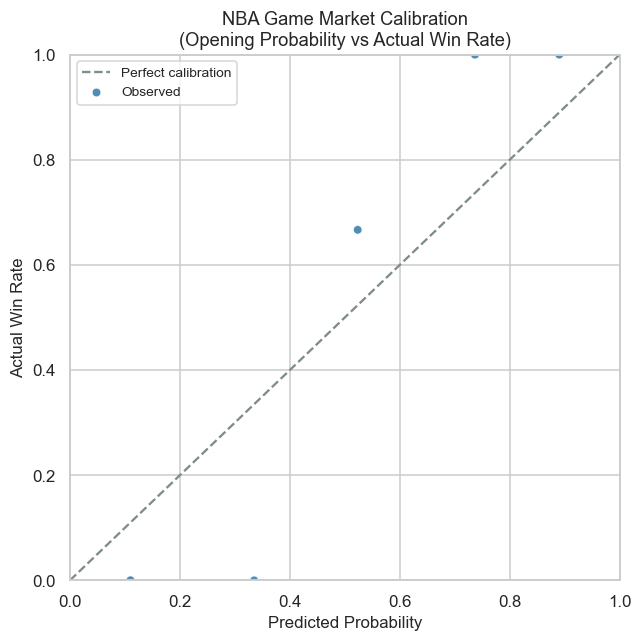

In [19]:
if histories and not settled_markets.empty and 'result' in settled_markets.columns:
    # settled last_price reflects settlement (1 or 99), not pre-game odds.
    # Use opening probability from trade histories as the "prediction" instead.
    market_summary = tables.create_market_summary(histories)
    result_map = settled_markets.set_index('ticker')['result']
    market_summary['result'] = market_summary['ticker'].map(result_map)
    market_summary = market_summary.dropna(subset=['result'])

    cal_input = pd.DataFrame({
        'last_price': (market_summary['open_prob'] * 100).round().astype(int),
        'result': market_summary['result'],
    })

    if len(cal_input) >= 5:
        cal_data = simulator.calibration_data(cal_input, n_bins=5)
        t4 = tables.create_calibration_table(cal_data)
        print('Table 4: Calibration — Opening Probability vs Actual Win Rate')
        print(f'(Based on {len(cal_input)} historical games)')
        print(t4.to_string(index=False))
        fig = plots.plot_calibration(
            cal_data,
            title='NBA Game Market Calibration\n(Opening Probability vs Actual Win Rate)'
        )
        plt.show()
    else:
        print(f'Only {len(cal_input)} matched games — not enough for calibration.')
else:
    print(f'Settled markets available: {len(settled_markets)}')
    if not settled_markets.empty:
        print(f'Columns: {list(settled_markets.columns)}')
    print('Calibration requires settled markets with a result column.')

---
## 7. Conclusion

This project built a prediction market simulator for NBA game outcome markets on Kalshi using live and historical trade data.

**Key findings:**

1. **Market structure** — The KXNBAGAME series offers binary win/loss markets for every NBA game. Most markets open away from 50%, reflecting genuine differences in team strength.

2. **Probability dynamics** — Market probabilities evolve as near-martingales on the logit scale, consistent with the Efficient Market Hypothesis. The estimated logit-scale volatility sigma captures the typical magnitude of probability swings per time step.

3. **Simulation** — The logit random walk model generates fan charts quantifying the range of possible outcomes from any starting probability. The bootstrap alternative produces similar but slightly fatter tails.

4. **Calibration** — We assess whether 70-cent contracts resolve YES approximately 70% of the time.

**References:**

- Kalshi API Documentation: https://docs.kalshi.com
- Manski, C. F. (2006). Interpreting the Predictions of Prediction Markets. Economics Letters, 91(3), 425-429.
- Wolfers, J., and Zitzewitz, E. (2004). Prediction Markets. Journal of Economic Perspectives, 18(2), 107-126.
- Black, F., and Scholes, M. (1973). The Pricing of Options and Corporate Liabilities. Journal of Political Economy, 81(3), 637-654.